# Task 6: House Price Prediction Model
**Objective:** Predict real estate property prices based on geometric and regional features using Machine Learning regression algorithms.
* **Target Variable:** `Price`
* **Predictor Features:** `Square_Footage`, `Bedrooms`, `Bathrooms`, `Location`

In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Set visualization styles
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

In [11]:
def load_or_create_data():
    csv_filename = "house_prices.csv"
    if os.path.exists(csv_filename):
        return pd.read_csv(csv_filename)
    
    np.random.seed(42)
    n_samples = 1500 # Slightly larger sample size for better training
    
    sq_ft = np.random.normal(1800, 600, n_samples).astype(int).clip(500)
    bedrooms = np.random.choice([1, 2, 3, 4, 5], size=n_samples, p=[0.1, 0.2, 0.4, 0.2, 0.1])
    bathrooms = (bedrooms - np.random.choice([0, 1], size=n_samples, p=[0.6, 0.4])).clip(1)
    location = np.random.choice(['Downtown', 'Urban', 'Suburbs', 'Rural'], size=n_samples, p=[0.25, 0.35, 0.3, 0.1])
    
    # Non-linear pricing formula with regional multipliers on square footage
    loc_sqft_rates = {'Downtown': 210, 'Urban': 155, 'Suburbs': 110, 'Rural': 65}
    base_rate = np.array([loc_sqft_rates[loc] for loc in location])
    
    price = 40000 + (sq_ft * base_rate) + (bedrooms * 22000) + (bathrooms * 18000)
    
    # Inject 3% extreme luxury outliers to simulate real-world market volatility
    outlier_indices = np.random.choice(n_samples, size=int(n_samples * 0.03), replace=False)
    price[outlier_indices] *= 1.8 
    
    price += np.random.normal(0, 25000, n_samples) # Realistic noise
    
    df = pd.DataFrame({
        'Square_Footage': sq_ft,
        'Bedrooms': bedrooms,
        'Bathrooms': bathrooms,
        'Location': location,
        'Price': price.astype(int)
    })
    df.to_csv(csv_filename, index=False)
    return df

df = load_or_create_data()
df.head()

,Square_Footage,Bedrooms,Bathrooms,Location,Price
0,2248,2,2,Downtown,585361
1,1930,2,2,Downtown,543562
2,2323,3,3,Downtown,677006
3,2761,4,4,Suburbs,522693
4,1882,2,1,Suburbs,345852


## Feature Engineering & Preprocessing Pipelines
We construct an automated `ColumnTransformer` pipeline:
1.  **Numerical Features** (`Square_Footage`, rooms): Scaled using `StandardScaler` to bring variance down to uniform scale distributions.
2.  **Categorical Features** (`Location` strings): Transformed into binary vector flags using `OneHotEncoder`.

In [12]:
# Separate Target and Features
X = df.drop(columns=['Price'])
y = df['Price']

# Define feature grouping vectors
numeric_features = ['Square_Footage', 'Bedrooms', 'Bathrooms']
categorical_features = ['Location']

# Preprocessing structures
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Data split allocation (80% Training dataset, 20% Testing evaluation)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training dataset size: {X_train.shape[0]} samples")
print(f"Testing dataset size: {X_test.shape[0]} samples")

Training dataset size: 800 samples
Testing dataset size: 200 samples


## Regression Training & Validation
We pipeline two algorithms for benchmark comparison:
* **Linear Regression** (Baseline reference framework)
* **Gradient Boosting Regressor** (Advanced modern ensemble technique)

In [13]:
models = {
    "Linear Regression": Pipeline(steps=[('preprocessor', preprocessor), ('regressor', LinearRegression())]),
    "Gradient Boosting": Pipeline(steps=[('preprocessor', preprocessor), ('regressor', HistGradientBoostingRegressor(random_state=42))])
}

results = {}

for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)
    
    # Mathematical performance indicators
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    
    results[name] = {
        'predictions': predictions,
        'MAE': mae,
        'RMSE': rmse
    }
    print(f"[{name}] Evaluation -> MAE: ${mae:,.2f} | RMSE: ${rmse:,.2f}")

[Linear Regression] Evaluation -> MAE: $20,416.73 | RMSE: $25,885.82
[Gradient Boosting] Evaluation -> MAE: $16,314.94 | RMSE: $21,260.32


## Actual vs. Predicted Visual Analysis
The charts below show actual property listing values plotted directly against the regression model predictions. The dotted red line represents a 100% accurate ideal fit match.

Calculating permutation feature importances...


C:\Users\Baryal Laptop\AppData\Local\Temp\ipykernel_6980\1586161018.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance Score', y='Feature', data=feat_df, palette="viridis", ax=axes[1, 1])


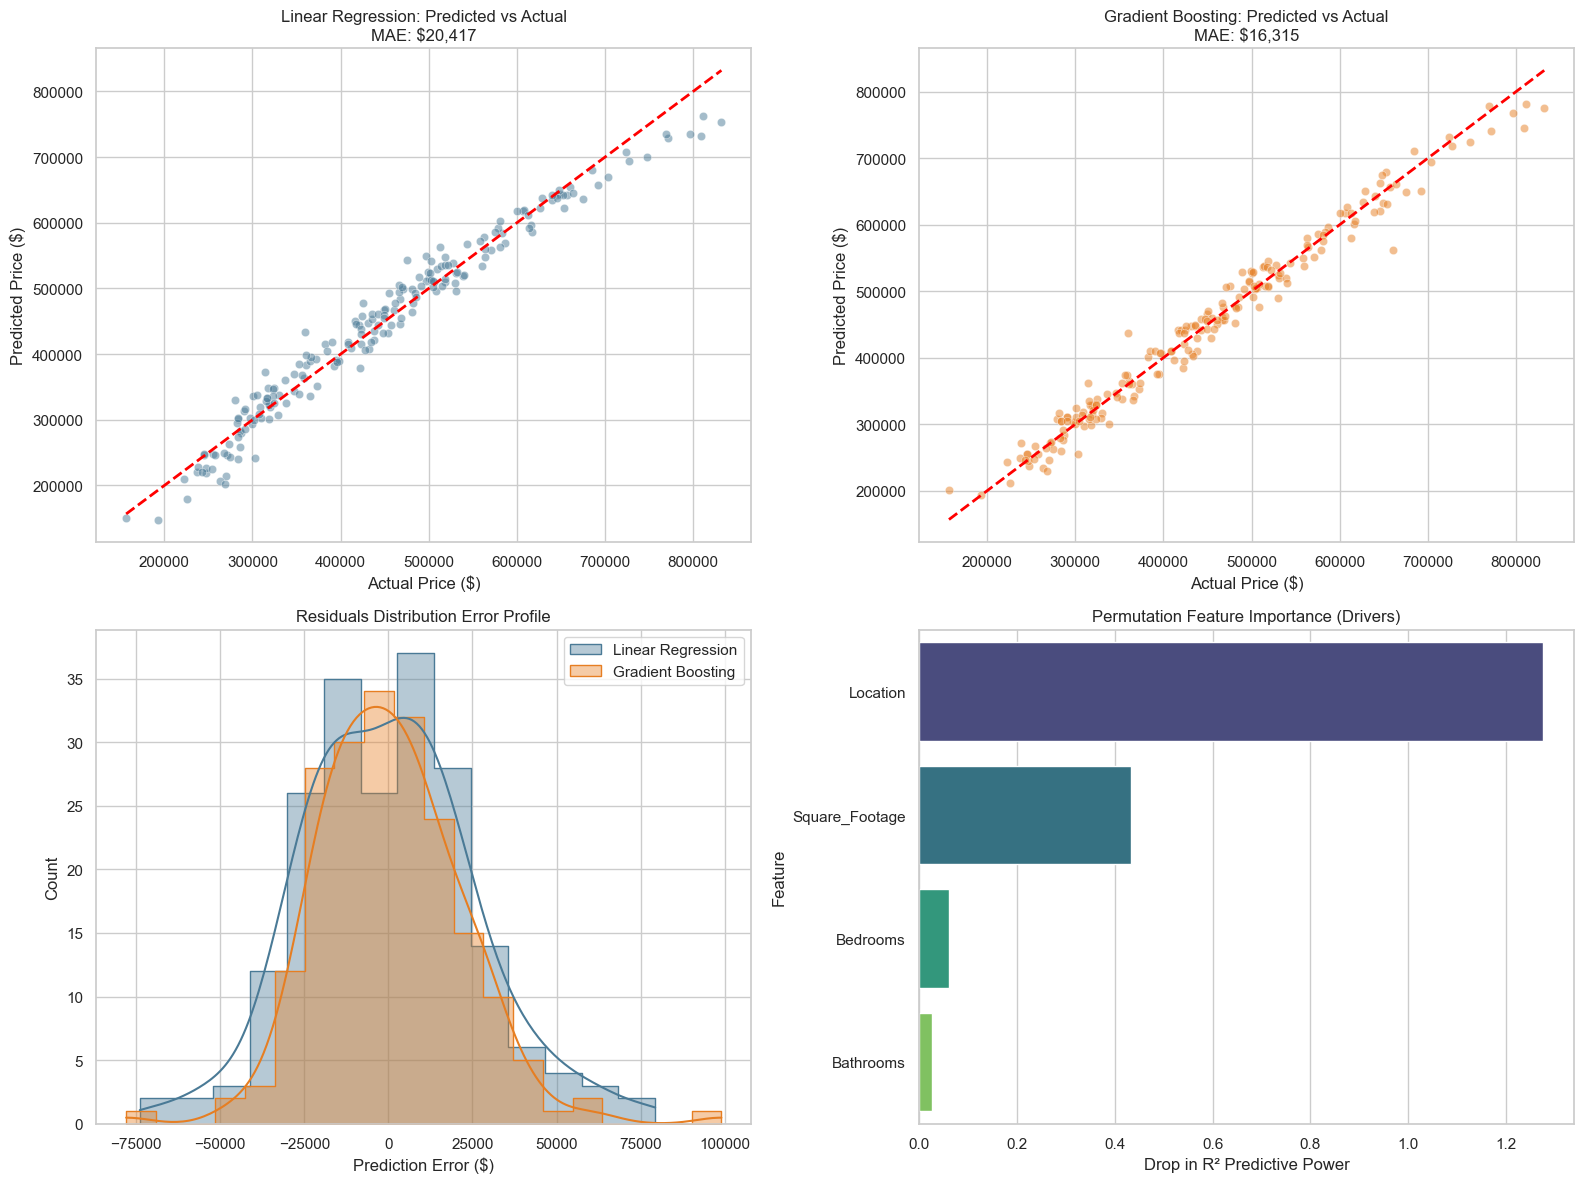

In [14]:
from sklearn.inspection import permutation_importance

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
colors = ['#4A7A96', '#E67E22']

# 1. Plot Predictions vs Actual for both models
for i, (name, metrics) in enumerate(results.items()):
    sns.scatterplot(x=y_test, y=metrics['predictions'], alpha=0.5, color=colors[i], ax=axes[0, i])
    perfect_line = [y_test.min(), y_test.max()]
    axes[0, i].plot(perfect_line, perfect_line, color='red', linestyle='--', linewidth=2)
    axes[0, i].set_title(f"{name}: Predicted vs Actual\nMAE: ${metrics['MAE']:,.0f}", fontsize=12)
    axes[0, i].set_xlabel("Actual Price ($)")
    axes[0, i].set_ylabel("Predicted Price ($)")

# 2. Residual Distribution Plot (Shows where errors aggregate)
for i, (name, metrics) in enumerate(results.items()):
    residuals = y_test - metrics['predictions']
    sns.histplot(residuals, kde=True, color=colors[i], ax=axes[1, 0], label=name, alpha=0.4, element="step")
axes[1, 0].set_title("Residuals Distribution Error Profile", fontsize=12)
axes[1, 0].set_xlabel("Prediction Error ($)")
axes[1, 0].legend()

# 3. FIXED STEP: Calculate Permutation Importance instead of using feature_importances_
print("Calculating permutation feature importances...")
gb_pipeline = models["Gradient Boosting"]
perm_importance = permutation_importance(gb_pipeline, X_test, y_test, n_repeats=10, random_state=42)

# Sort features by their importance mean score
sorted_importances_idx = perm_importance.importances_mean.argsort()[::-1]
sorted_features = X_test.columns[sorted_importances_idx]
sorted_scores = perm_importance.importances_mean[sorted_importances_idx]

# Map variables onto a neat DataFrame for plotting
feat_df = pd.DataFrame({'Feature': sorted_features, 'Importance Score': sorted_scores})

sns.barplot(x='Importance Score', y='Feature', data=feat_df, palette="viridis", ax=axes[1, 1])
axes[1, 1].set_title("Permutation Feature Importance (Drivers)", fontsize=12)
axes[1, 1].set_xlabel("Drop in R² Predictive Power")

plt.tight_layout()
plt.show()